# Introduction to Sampling Algorithms — A Visual Walkthrough
---

We start with one primitive — a uniform random number generator — and build three increasingly flexible methods to sample from arbitrary distributions:

1. Why sampling is hard
2. Inverse Transform Sampling
3. Rejection Sampling
4. Importance Sampling
5. Summary

This notebook creates all plots and animations referenced in the companion blogpost.

---

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.animation import FuncAnimation
from scipy import stats
import scienceplots

plt.style.use(['science', 'ieee'])
plt.rcParams.update({
    'figure.figsize': (10, 4),
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

np.random.seed(42)

from IPython.display import HTML

print("Ready to go!")

Ready to go!


---
## 1. The Primitive: Uniform Random Numbers

Everything starts with a black box that gives us numbers from 0 to 1 with equal probability.

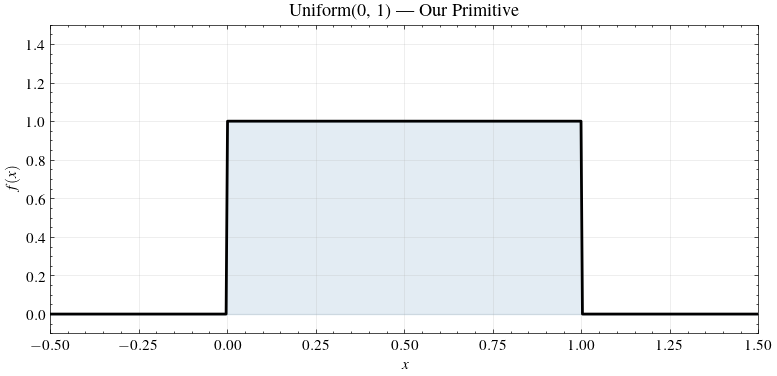

In [2]:
fig, ax = plt.subplots(figsize=(8, 4))

x_u = np.linspace(-0.5, 1.5, 500)
pdf_u = np.where((x_u >= 0) & (x_u <= 1), 1.0, 0.0)
ax.plot(x_u, pdf_u, 'k-', lw=2)
ax.fill_between(x_u, pdf_u, alpha=0.15, color='steelblue')
ax.set_xlabel('$x$')
ax.set_ylabel('$f(x)$')
ax.set_title('Uniform(0, 1) — Our Primitive')
ax.set_ylim(-0.1, 1.5)
ax.set_xlim(-0.5, 1.5)

plt.tight_layout()
plt.show()

---
## 1.1 Why Sampling is Hard

Suppose you want to recreate a Gaussian by manually placing samples along the x-axis. Intuition tells you to put more samples near the center — but how does a computer learn that?

The interactive cell below simulates this: click "Run" and watch how random uniform samples fail to recreate the target shape, while properly sampled points match it.

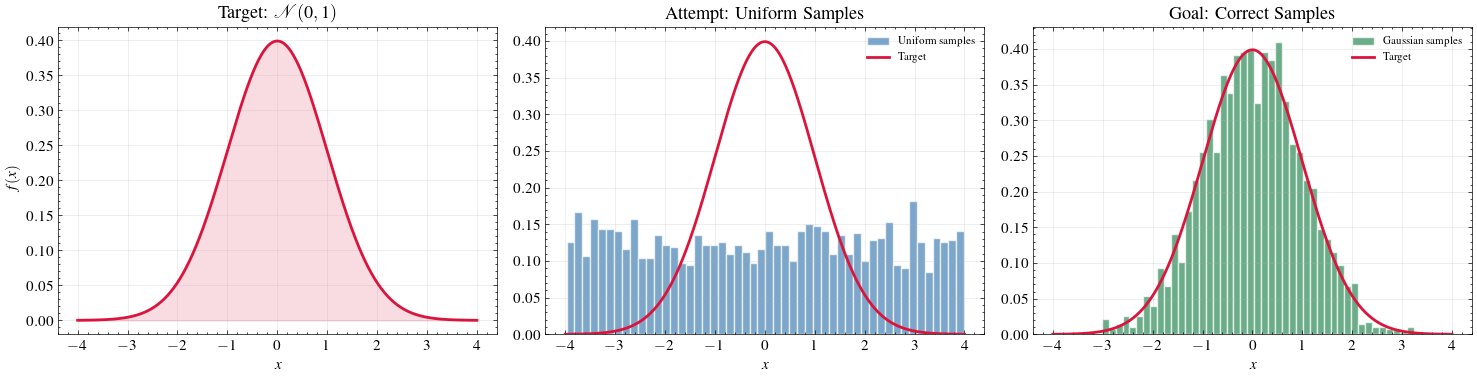

Uniform samples give a flat histogram — nothing like the bell curve.
We need algorithms that concentrate samples where the density is high.


In [3]:
np.random.seed(42)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

x_grid = np.linspace(-4, 4, 500)
gaussian_pdf = stats.norm.pdf(x_grid)

axes[0].plot(x_grid, gaussian_pdf, 'crimson', lw=2)
axes[0].fill_between(x_grid, gaussian_pdf, alpha=0.15, color='crimson')
axes[0].set_title('Target: $\\mathcal{N}(0, 1)$')
axes[0].set_xlabel('$x$')
axes[0].set_ylabel('$f(x)$')

uniform_samples = np.random.uniform(-4, 4, 2000)
axes[1].hist(uniform_samples, bins=50, density=True, color='steelblue',
             edgecolor='white', alpha=0.7, label='Uniform samples')
axes[1].plot(x_grid, gaussian_pdf, 'crimson', lw=2, label='Target')
axes[1].set_title('Attempt: Uniform Samples')
axes[1].set_xlabel('$x$')
axes[1].legend(fontsize=8)

gaussian_samples = np.random.normal(0, 1, 2000)
axes[2].hist(gaussian_samples, bins=50, density=True, color='seagreen',
             edgecolor='white', alpha=0.7, label='Gaussian samples')
axes[2].plot(x_grid, gaussian_pdf, 'crimson', lw=2, label='Target')
axes[2].set_title('Goal: Correct Samples')
axes[2].set_xlabel('$x$')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print("Uniform samples give a flat histogram — nothing like the bell curve.")
print("We need algorithms that concentrate samples where the density is high.")

---
## 2. Inverse Transform Sampling

The idea: use the CDF to map uniform random numbers to the target distribution. Let's walk through the exponential distribution as an example.

### The Exponential Distribution

$$f_X(x) = \lambda e^{-\lambda x}, \quad x \geq 0$$

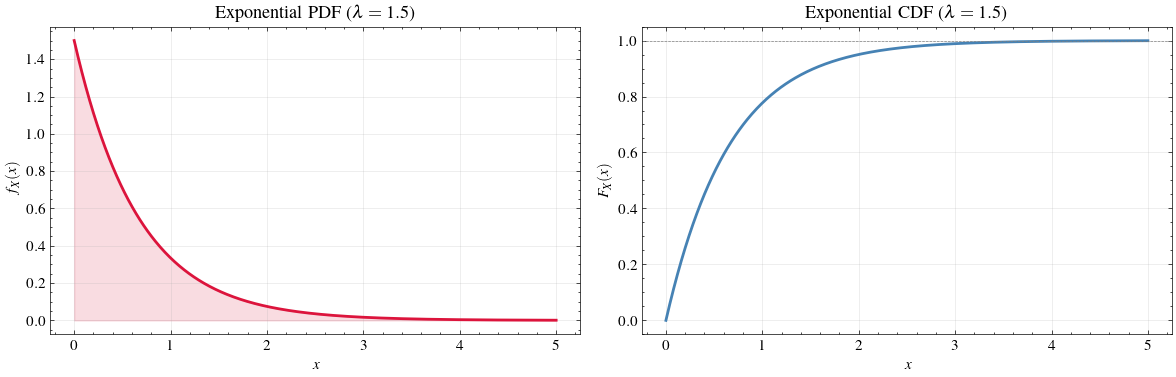

In [4]:
lam = 1.5  # rate parameter

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x = np.linspace(0, 5, 500)
pdf_exp = lam * np.exp(-lam * x)
cdf_exp = 1 - np.exp(-lam * x)

axes[0].plot(x, pdf_exp, 'crimson', lw=2)
axes[0].fill_between(x, pdf_exp, alpha=0.15, color='crimson')
axes[0].set_xlabel('$x$')
axes[0].set_ylabel('$f_X(x)$')
axes[0].set_title(f'Exponential PDF ($\\lambda = {lam}$)')

axes[1].plot(x, cdf_exp, 'steelblue', lw=2)
axes[1].set_xlabel('$x$')
axes[1].set_ylabel('$F_X(x)$')
axes[1].set_title(f'Exponential CDF ($\\lambda = {lam}$)')
axes[1].set_ylim(-0.05, 1.05)
axes[1].axhline(1, ls='--', color='grey', lw=0.5)

plt.tight_layout()
plt.show()

### The Geometric Mechanism

Pick a random point $u$ on the y-axis (0 to 1), draw a horizontal line to the CDF curve, then drop down to the x-axis. That x-value is your sample.

The CDF is **steeper** where the density is higher — so more of the y-axis maps to those high-density x-values.

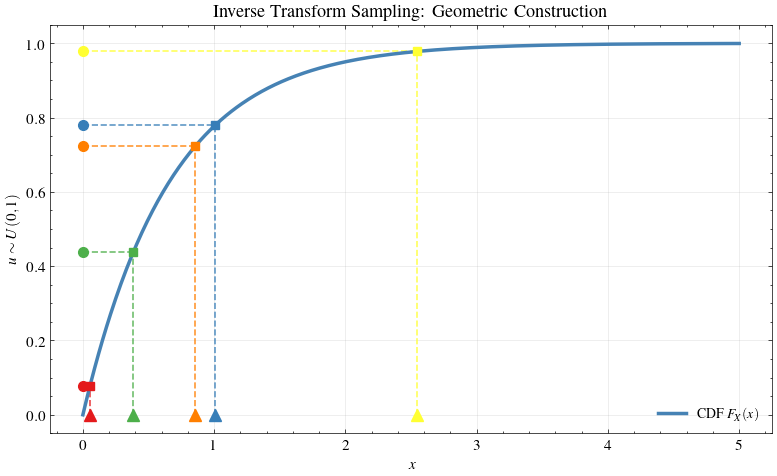

Each color: pick u on y-axis -> trace to CDF -> drop to x-axis -> that's your sample.
More y-axis maps to small x-values (steep CDF) -> more samples there.


In [5]:
np.random.seed(7)

fig, ax = plt.subplots(figsize=(8, 5))

x = np.linspace(0, 5, 500)
cdf_exp = 1 - np.exp(-lam * x)
ax.plot(x, cdf_exp, 'steelblue', lw=2.5, label='CDF $F_X(x)$', zorder=3)

u_samples = np.random.uniform(0, 1, 5)
colors = plt.cm.Set1(np.linspace(0, 0.6, 5))

for u, c in zip(u_samples, colors):
    x_val = -np.log(1 - u) / lam
    ax.plot([0, x_val], [u, u], '--', color=c, lw=1.2, alpha=0.8)
    ax.plot([x_val, x_val], [0, u], '--', color=c, lw=1.2, alpha=0.8)
    ax.plot(0, u, 'o', color=c, ms=7, zorder=5)
    ax.plot(x_val, u, 's', color=c, ms=6, zorder=5)
    ax.plot(x_val, 0, '^', color=c, ms=8, zorder=5)

ax.set_xlabel('$x$')
ax.set_ylabel('$u \\sim U(0,1)$')
ax.set_title('Inverse Transform Sampling: Geometric Construction')
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print("Each color: pick u on y-axis -> trace to CDF -> drop to x-axis -> that's your sample.")
print("More y-axis maps to small x-values (steep CDF) -> more samples there.")

### Animation: Inverse Transform Sampling in Action

Watch uniform values on the y-axis get mapped through the CDF to produce exponential samples.

In [ ]:
np.random.seed(42)

n_frames = 80
u_vals = np.random.uniform(0, 1, n_frames)
x_vals = -np.log(1 - u_vals) / lam

fig = plt.figure(figsize=(12, 5), dpi=100)
gs = gridspec.GridSpec(1, 2, width_ratios=[1.2, 1])
ax_cdf = fig.add_subplot(gs[0])
ax_hist = fig.add_subplot(gs[1])
plt.close(fig)

x_curve = np.linspace(0, 5, 500)
cdf_curve = 1 - np.exp(-lam * x_curve)
pdf_curve = lam * np.exp(-lam * x_curve)

def animate_its(frame):
    u = u_vals[frame]
    x_s = x_vals[frame]

    # CDF panel
    ax_cdf.clear()
    ax_cdf.plot(x_curve, cdf_curve, 'steelblue', lw=2.5)
    ax_cdf.set_xlabel('$x$')
    ax_cdf.set_ylabel('$u$')
    ax_cdf.set_title(f'CDF Mapping (sample {frame+1}/{n_frames})')
    ax_cdf.set_ylim(-0.05, 1.05)
    ax_cdf.set_xlim(-0.2, 5)

    # Show previous samples as faded dots
    if frame > 0:
        ax_cdf.scatter(x_vals[:frame], u_vals[:frame], s=10, alpha=0.2, color='grey', zorder=2)

    # Current sample construction lines
    ax_cdf.plot([0, x_s], [u, u], '--', color='crimson', lw=1.5)
    ax_cdf.plot([x_s, x_s], [0, u], '--', color='crimson', lw=1.5)
    ax_cdf.plot(0, u, 'o', color='crimson', ms=8, zorder=5)
    ax_cdf.plot(x_s, u, 's', color='crimson', ms=7, zorder=5)
    ax_cdf.plot(x_s, 0, '^', color='crimson', ms=9, zorder=5)

    # Histogram panel
    ax_hist.clear()
    ax_hist.hist(x_vals[:frame+1], bins=30, density=True, color='steelblue',
                 edgecolor='white', alpha=0.7, range=(0, 5))
    ax_hist.plot(x_curve, pdf_curve, 'crimson', lw=2, label='True PDF')
    ax_hist.set_xlabel('$x$')
    ax_hist.set_ylabel('Density')
    ax_hist.set_title(f'Emerging Exponential ($n={frame+1}$)')
    ax_hist.set_xlim(0, 5)
    ax_hist.set_ylim(0, 2)
    ax_hist.legend(fontsize=9)

    fig.tight_layout()

anim_its = FuncAnimation(fig, animate_its, frames=n_frames, interval=150, repeat=False)
HTML(anim_its.to_jshtml())

> **Key insight:** inverse transform sampling produces exact samples with no waste — every uniform draw yields a valid sample. The limitation is that we need a closed-form inverse CDF, which most distributions don't have.

---
## 3. Rejection Sampling

When the inverse CDF isn't available, we can use rejection sampling. The idea: draw a candidate from a simple proposal distribution and then randomly accept or reject it based on how well the proposal matches the target.

### The Target Distribution

$$p(x) = e^{-x^2/2} \cdot (\sin^2(6+x) + 3 \cos^2(x) \sin^2(4x) + 1)$$

This is intentionally complex — no closed-form CDF exists.

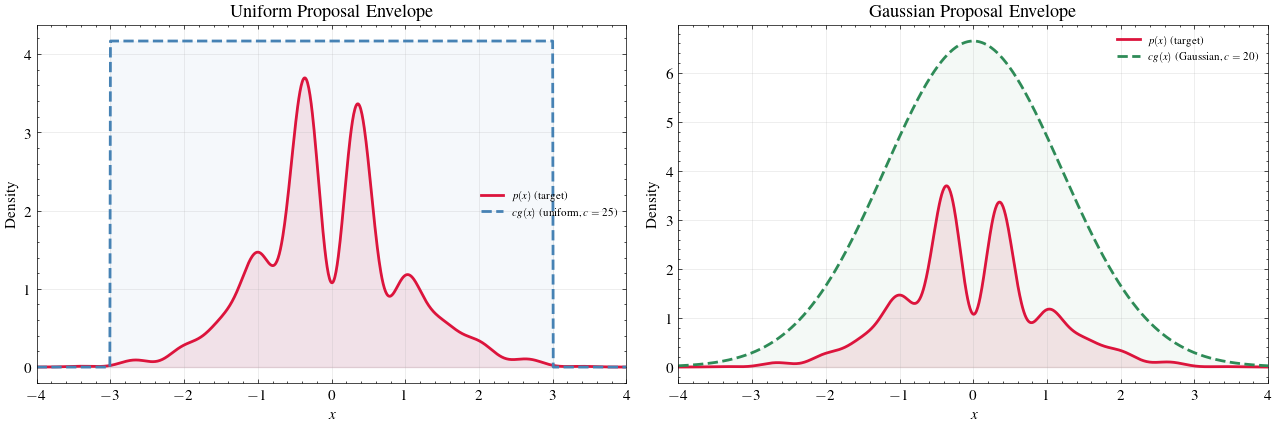

The proposal cg(x) must fully envelop p(x).
A tighter envelope (Gaussian) wastes less area -> higher acceptance rate.


In [7]:
def target_pdf(x):
    """Unnormalized target distribution."""
    return np.exp(-x**2 / 2) * (np.sin(6 + x)**2 + 3 * np.cos(x)**2 * np.sin(4*x)**2 + 1)

x_grid = np.linspace(-4, 4, 1000)
target_vals = target_pdf(x_grid)

# Proposal 1: Uniform on [-3, 3]
c_uniform = 25
proposal_uniform = np.where((x_grid >= -3) & (x_grid <= 3), c_uniform / 6, 0)

# Proposal 2: Scaled Gaussian
c_gauss = 20
proposal_gauss = c_gauss * stats.norm.pdf(x_grid, 0, 1.2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, proposal, label, color, c_val in [
    (axes[0], proposal_uniform, 'uniform', 'steelblue', c_uniform),
    (axes[1], proposal_gauss, 'Gaussian', 'seagreen', c_gauss),
]:
    ax.plot(x_grid, target_vals, 'crimson', lw=2, label='$p(x)$ (target)')
    ax.fill_between(x_grid, target_vals, alpha=0.1, color='crimson')
    ax.plot(x_grid, proposal, color, lw=2, ls='--', label=f'$cg(x)$ ({label}, $c={c_val}$)')
    ax.fill_between(x_grid, proposal, alpha=0.05, color=color)
    ax.set_xlabel('$x$')
    ax.set_ylabel('Density')
    ax.set_title(f'{label.title()} Proposal Envelope')
    ax.legend(fontsize=8)
    ax.set_xlim(-4, 4)

plt.tight_layout()
plt.show()

print("The proposal cg(x) must fully envelop p(x).")
print("A tighter envelope (Gaussian) wastes less area -> higher acceptance rate.")

### The Accept/Reject Mechanism (Rotated View)

To build intuition, let's look at a single candidate $x = -1$. We draw a uniform number along the vertical line from the x-axis up to the proposal envelope. If it falls below the target, we accept; otherwise, we reject.

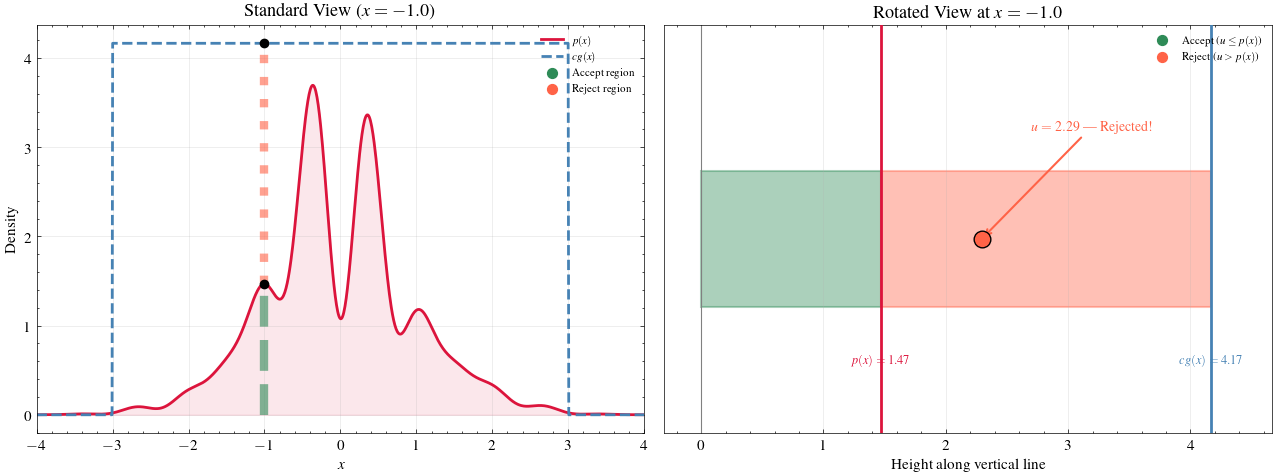

At x = -1.0: p(x) = 1.47, cg(x) = 4.17
Acceptance probability = p(x)/cg(x) = 35.2%


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x_sample = -1.0
p_val = target_pdf(x_sample)
cg_val = c_uniform / 6  # uniform proposal height

# (a) Standard view with vertical line
ax = axes[0]
ax.plot(x_grid, target_vals, 'crimson', lw=2, label='$p(x)$')
ax.fill_between(x_grid, target_vals, alpha=0.1, color='crimson')
ax.plot(x_grid, proposal_uniform, 'steelblue', lw=2, ls='--', label='$cg(x)$')

# Vertical line: accept (green) and reject (red) segments
ax.plot([x_sample, x_sample], [0, p_val], color='seagreen', lw=6, alpha=0.6, zorder=4)
ax.plot([x_sample, x_sample], [p_val, cg_val], color='tomato', lw=6, alpha=0.6, zorder=4)
ax.plot(x_sample, p_val, 'ko', ms=6, zorder=5)
ax.plot(x_sample, cg_val, 'ko', ms=6, zorder=5)

# Legend with matching circle markers for accept/reject
ax.scatter([], [], marker='o', color='seagreen', s=50, label='Accept region')
ax.scatter([], [], marker='o', color='tomato', s=50, label='Reject region')

ax.set_xlabel('$x$')
ax.set_ylabel('Density')
ax.set_title(f'Standard View ($x = {x_sample}$)')
ax.legend(fontsize=8, loc='upper right')
ax.set_xlim(-4, 4)

# (b) Rotated (zoomed) view of the vertical line at x = -1
ax = axes[1]

# Draw the full bar from 0 to cg(x) split into accept and reject
bar_h = 0.35
ax.barh(0, p_val, height=bar_h, color='seagreen', alpha=0.4,
        edgecolor='seagreen', lw=1.5)
ax.barh(0, cg_val - p_val, left=p_val, height=bar_h, color='tomato', alpha=0.4,
        edgecolor='tomato', lw=1.5)

# Boundary markers
ax.axvline(p_val, ls='-', color='crimson', lw=2, zorder=3)
ax.axvline(cg_val, ls='-', color='steelblue', lw=2, zorder=3)
ax.axvline(0, ls='-', color='grey', lw=0.8)

# Labels at boundaries
ax.text(p_val, -0.32, f'$p(x)={p_val:.2f}$', ha='center', fontsize=9,
        color='crimson', fontweight='bold')
ax.text(cg_val, -0.32, f'$cg(x)={cg_val:.2f}$', ha='center', fontsize=9,
        color='steelblue', fontweight='bold')

# Sample a u to show accept/reject decision
np.random.seed(3)
u_sample = np.random.uniform(0, cg_val)
accepted = u_sample <= p_val
pt_color = 'seagreen' if accepted else 'tomato'
label_u = 'Accepted!' if accepted else 'Rejected!'
ax.plot(u_sample, 0, 'o', color=pt_color, ms=12, zorder=5, markeredgecolor='black', markeredgewidth=1)
ax.annotate(f'$u = {u_sample:.2f}$ — {label_u}',
            xy=(u_sample, 0), xytext=(u_sample + 0.4, 0.28),
            fontsize=10, fontweight='bold', color=pt_color,
            arrowprops=dict(arrowstyle='->', color=pt_color, lw=1.5))

# Legend — same circle symbol, differentiated by color
ax.scatter([], [], marker='o', color='seagreen', s=50, label='Accept ($u \\leq p(x)$)')
ax.scatter([], [], marker='o', color='tomato', s=50, label='Reject ($u > p(x)$)')

ax.set_xlabel('Height along vertical line')
ax.set_title(f'Rotated View at $x = {x_sample}$')
ax.set_xlim(-0.3, cg_val + 0.5)
ax.set_ylim(-0.5, 0.55)
ax.set_yticks([])
ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

print(f"At x = {x_sample}: p(x) = {p_val:.2f}, cg(x) = {cg_val:.2f}")
print(f"Acceptance probability = p(x)/cg(x) = {p_val/cg_val:.1%}")

### The Rejection Sampling Algorithm

```
Rejection Sampling
──────────────────────────────────────
Input:  target p(x), proposal g(x), constant c such that cg(x) ≥ p(x) ∀x
Output: a sample from p(x)

1. Draw x ~ g(x)
2. Draw u ~ Uniform(0, 1)
3. If u ≤ p(x) / (c · g(x)):
       Accept x
   Else:
       Reject x, go to step 1
```

### Animation: Rejection Sampling with a Gaussian Proposal

Green points are accepted, red points are rejected. The accepted points reconstruct the target distribution.

In [ ]:
np.random.seed(42)

proposal_mu, proposal_sigma = 0, 1.2
c_g = 20

# Realistic single-pass rejection sampling
n_target = 400
timeline_x, timeline_y, timeline_acc = [], [], []

while sum(timeline_acc) < n_target if timeline_acc else True:
    x_s = np.random.normal(proposal_mu, proposal_sigma)
    u_s = np.random.uniform(0, 1)
    cg_val = c_g * stats.norm.pdf(x_s, proposal_mu, proposal_sigma)
    if cg_val == 0:
        continue
    p_val = target_pdf(x_s)
    y_pt = u_s * cg_val
    accepted = u_s <= p_val / cg_val
    timeline_x.append(x_s)
    timeline_y.append(y_pt)
    timeline_acc.append(accepted)
    if sum(timeline_acc) >= n_target:
        break

total_points = len(timeline_x)
n_anim_frames = min(150, total_points)
step = max(1, total_points // n_anim_frames)

fig = plt.figure(figsize=(13, 5), dpi=100)
gs = gridspec.GridSpec(1, 2, width_ratios=[1.2, 1])
ax_scatter = fig.add_subplot(gs[0])
ax_hist = fig.add_subplot(gs[1])
plt.close(fig)

x_curve = np.linspace(-4, 4, 500)
target_curve = target_pdf(x_curve)
proposal_curve = c_g * stats.norm.pdf(x_curve, proposal_mu, proposal_sigma)
Z = np.trapezoid(target_curve, x_curve)

tl_x = np.array(timeline_x)
tl_y = np.array(timeline_y)
tl_acc = np.array(timeline_acc)

def animate_rs(frame):
    idx = min((frame + 1) * step, total_points)

    ax_scatter.clear()
    ax_scatter.plot(x_curve, target_curve, 'crimson', lw=2, label='$p(x)$')
    ax_scatter.plot(x_curve, proposal_curve, 'grey', lw=1.5, ls='--', label='$cg(x)$', alpha=0.6)

    acc_mask = tl_acc[:idx]
    xs, ys = tl_x[:idx], tl_y[:idx]

    if acc_mask.any():
        ax_scatter.scatter(xs[acc_mask], ys[acc_mask], s=8, color='seagreen', alpha=0.5, label='Accepted', zorder=4)
    if (~acc_mask).any():
        ax_scatter.scatter(xs[~acc_mask], ys[~acc_mask], s=8, color='tomato', alpha=0.3, label='Rejected', zorder=3)

    n_acc = acc_mask.sum()
    n_rej = (~acc_mask).sum()
    rate = n_acc / max(idx, 1) * 100
    ax_scatter.set_title(f'Rejection Sampling ({n_acc} acc, {n_rej} rej, rate={rate:.0f}%)')
    ax_scatter.set_xlabel('$x$')
    ax_scatter.set_ylabel('Height')
    ax_scatter.set_xlim(-4, 4)
    ax_scatter.legend(fontsize=7, loc='upper right')

    ax_hist.clear()
    if n_acc > 1:
        ax_hist.hist(xs[acc_mask], bins=40, density=True, color='seagreen',
                     edgecolor='white', alpha=0.7, range=(-4, 4))
    ax_hist.plot(x_curve, target_curve / Z, 'crimson', lw=2, label='True (normalized)')
    ax_hist.set_xlabel('$x$')
    ax_hist.set_ylabel('Density')
    ax_hist.set_title(f'Accepted Samples ($n={n_acc}$)')
    ax_hist.set_xlim(-4, 4)
    ax_hist.set_ylim(0, 0.6)
    ax_hist.legend(fontsize=9)

    fig.tight_layout()

anim_rs = FuncAnimation(fig, animate_rs, frames=n_anim_frames, interval=100, repeat=False)
HTML(anim_rs.to_jshtml())

> **Notice:** the Gaussian proposal yields a much higher acceptance rate than the uniform would. Points under the target curve are accepted (green) — their density matches $p(x)$.

---
## 4. Importance Sampling

Importance sampling is not a sampling algorithm in the same sense — it's a **variance reduction technique** for estimating expectations. But it's foundational and connects directly to the methods above.

### Background: Expected Value, LOTUS, and Monte Carlo

Given $N$ samples $x_i \sim f_X(x)$, the Monte Carlo estimator is:

$$E[g(X)] \approx \frac{1}{N} \sum_{i=1}^{N} g(x_i)$$

### The Importance Sampling Trick

$$E_p[g(X)] = \int g(x) p(x) dx = \int g(x) \frac{p(x)}{q(x)} q(x) dx = E_q\left[g(X) \cdot \frac{p(X)}{q(X)}\right]$$

We've rewritten an expectation under $p$ (which we can't sample from) as one under $q$ (which we can).

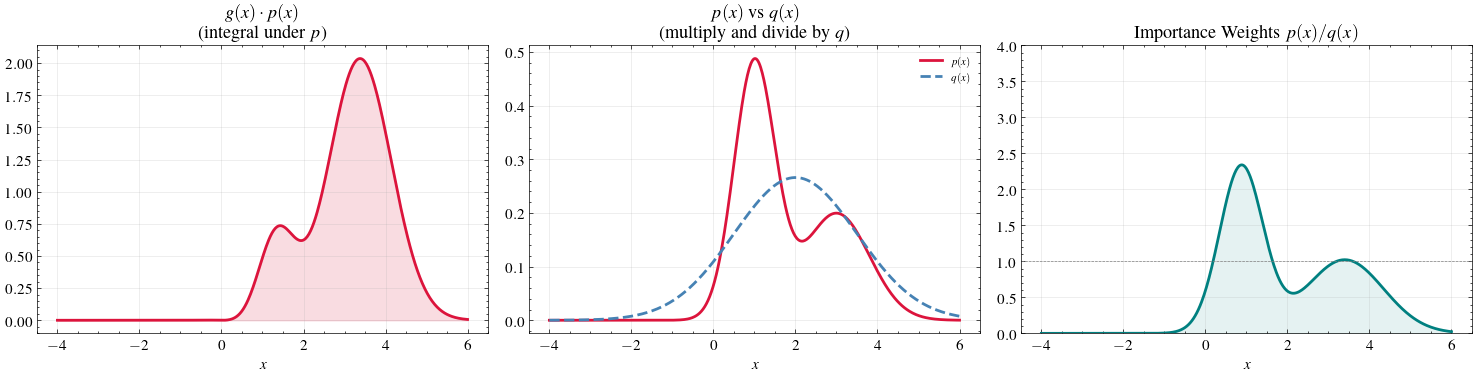

The importance weight p(x)/q(x) corrects for the mismatch between p and q.
Where q underestimates p, weights are large (those samples count more).
Where q overestimates p, weights are small (those samples count less).


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

x = np.linspace(-4, 6, 500)

# p(x): target we can't sample from (a skewed bimodal)
p_x = 0.6 * stats.norm.pdf(x, 1, 0.5) + 0.4 * stats.norm.pdf(x, 3, 0.8)
# g(x): the function we want the expectation of
g_x = x ** 2
# q(x): proposal we can sample from
q_x = stats.norm.pdf(x, 2, 1.5)

# (a) The original integral: g(x) * p(x)
integrand_p = g_x * p_x
axes[0].plot(x, integrand_p, 'crimson', lw=2)
axes[0].fill_between(x, integrand_p, alpha=0.15, color='crimson')
axes[0].set_title('$g(x) \\cdot p(x)$\n(integral under $p$)')
axes[0].set_xlabel('$x$')

# (b) The reweighted integrand
weights = np.where(q_x > 1e-10, p_x / q_x, 0)
axes[1].plot(x, p_x, 'crimson', lw=2, label='$p(x)$')
axes[1].plot(x, q_x, 'steelblue', lw=2, ls='--', label='$q(x)$')
axes[1].set_title('$p(x)$ vs $q(x)$\n(multiply and divide by $q$)')
axes[1].set_xlabel('$x$')
axes[1].legend(fontsize=8)

# (c) Importance weights
axes[2].plot(x, weights, 'teal', lw=2)
axes[2].fill_between(x, weights, alpha=0.1, color='teal')
axes[2].axhline(1, ls='--', color='grey', lw=0.5)
axes[2].set_title('Importance Weights $p(x)/q(x)$')
axes[2].set_xlabel('$x$')
axes[2].set_ylim(0, 4)

plt.tight_layout()
plt.show()

print("The importance weight p(x)/q(x) corrects for the mismatch between p and q.")
print("Where q underestimates p, weights are large (those samples count more).")
print("Where q overestimates p, weights are small (those samples count less).")

### Building Intuition: The Rigged Die

Imagine a rigged die where face 6 comes up half the time. We want to estimate the expected value under this rigged die, but all we have is a fair die.

The importance weights correct the mismatch: face 6 gets weight $\frac{1/2}{1/6} = 3$, while face 1 gets weight $\frac{1/10}{1/6} = 0.6$.

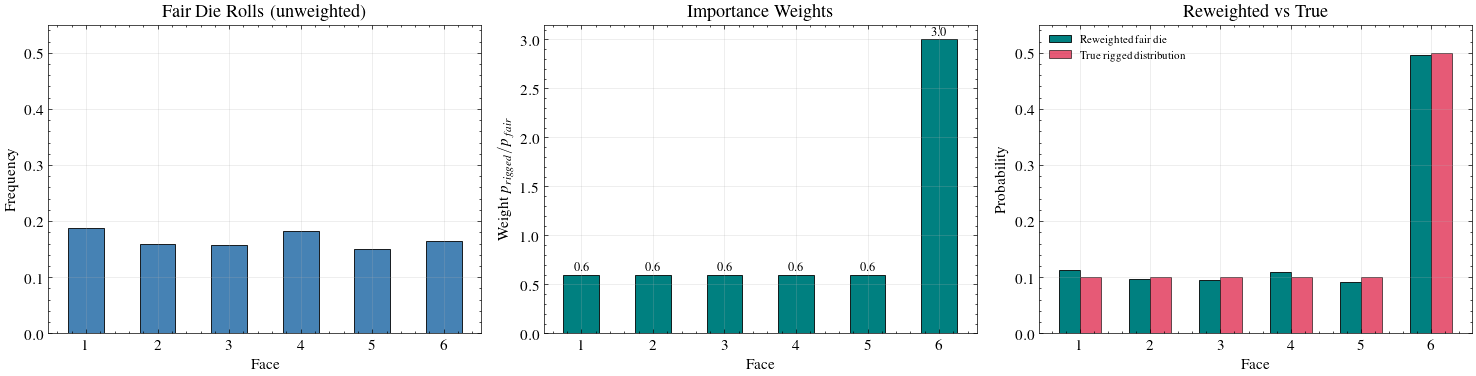

True E[X] under rigged die: 4.500
Naive estimate (fair die):  3.443  (biased — ignores rigging)
Importance sampling est.:   4.427  (corrected via weights)


In [11]:
np.random.seed(42)

faces = np.arange(1, 7)
p_rigged = np.array([0.1, 0.1, 0.1, 0.1, 0.1, 0.5])  # rigged: face 6 = 50%
p_fair = np.ones(6) / 6  # fair die

# Roll a fair die N times
N = 1000
rolls = np.random.choice(faces, size=N, p=p_fair)

# Compute importance weights
weights_die = p_rigged[rolls - 1] / p_fair[rolls - 1]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (a) Fair die frequencies
ax = axes[0]
fair_counts = np.bincount(rolls, minlength=7)[1:]
ax.bar(faces, fair_counts / N, width=0.5, color='steelblue', edgecolor='black', lw=0.6)
ax.set_xlabel('Face')
ax.set_ylabel('Frequency')
ax.set_title('Fair Die Rolls (unweighted)')
ax.set_xticks(faces)
ax.set_ylim(0, 0.55)

# (b) Importance weights
ax = axes[1]
w_display = p_rigged / p_fair
bars = ax.bar(faces, w_display, width=0.5, color='teal', edgecolor='black', lw=0.6)
ax.set_xlabel('Face')
ax.set_ylabel('Weight $p_{rigged}/p_{fair}$')
ax.set_title('Importance Weights')
ax.set_xticks(faces)
for bar, w in zip(bars, w_display):
    ax.text(bar.get_x() + bar.get_width()/2, w + 0.05, f'{w:.1f}',
            ha='center', fontsize=9)

# (c) Reweighted histogram vs true rigged distribution
ax = axes[2]
weighted_counts = np.zeros(6)
for f, w in zip(rolls, weights_die):
    weighted_counts[f - 1] += w
weighted_freq = weighted_counts / weighted_counts.sum()

x_pos = np.arange(6)
w_bar = 0.3
ax.bar(x_pos - w_bar/2, weighted_freq, w_bar, color='teal', edgecolor='black', lw=0.6,
       label='Reweighted fair die')
ax.bar(x_pos + w_bar/2, p_rigged, w_bar, color='crimson', edgecolor='black', lw=0.6,
       alpha=0.7, label='True rigged distribution')
ax.set_xlabel('Face')
ax.set_ylabel('Probability')
ax.set_title('Reweighted vs True')
ax.set_xticks(x_pos)
ax.set_xticklabels(faces)
ax.set_ylim(0, 0.55)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Expected value comparison
true_ev = np.sum(faces * p_rigged)
naive_ev = np.mean(rolls)
is_ev = np.mean(rolls * weights_die)

print(f"True E[X] under rigged die: {true_ev:.3f}")
print(f"Naive estimate (fair die):  {naive_ev:.3f}  (biased — ignores rigging)")
print(f"Importance sampling est.:   {is_ev:.3f}  (corrected via weights)")

### Why the Choice of $q$ Matters: Good vs Bad Proposal

Mathematically, any $q(x) > 0$ where $p(x) > 0$ gives a valid estimator. But the variance depends critically on how well $q$ matches $p$.

In [12]:
np.random.seed(42)

# Target: compute E_p[g(X)] where p(x) = N(2, 0.5^2), g(x) = x^2
p_mu, p_sigma = 2.0, 0.5
true_val = p_mu**2 + p_sigma**2  # E[X^2] = mu^2 + sigma^2 = 4.25

# Good proposal: close to p
q_good_mu, q_good_sigma = 2.0, 0.8
# Bad proposal: far from p
q_bad_mu, q_bad_sigma = -1.0, 2.0

n_samples = 500
n_trials = 200

estimates_good = []
estimates_bad = []

for _ in range(n_trials):
    # Good proposal
    x_good = np.random.normal(q_good_mu, q_good_sigma, n_samples)
    w_good = stats.norm.pdf(x_good, p_mu, p_sigma) / stats.norm.pdf(x_good, q_good_mu, q_good_sigma)
    est_good = np.cumsum(x_good**2 * w_good) / np.arange(1, n_samples + 1)
    estimates_good.append(est_good)

    # Bad proposal
    x_bad = np.random.normal(q_bad_mu, q_bad_sigma, n_samples)
    w_bad = stats.norm.pdf(x_bad, p_mu, p_sigma) / stats.norm.pdf(x_bad, q_bad_mu, q_bad_sigma)
    est_bad = np.cumsum(x_bad**2 * w_bad) / np.arange(1, n_samples + 1)
    estimates_bad.append(est_bad)

estimates_good = np.array(estimates_good)
estimates_bad = np.array(estimates_bad)

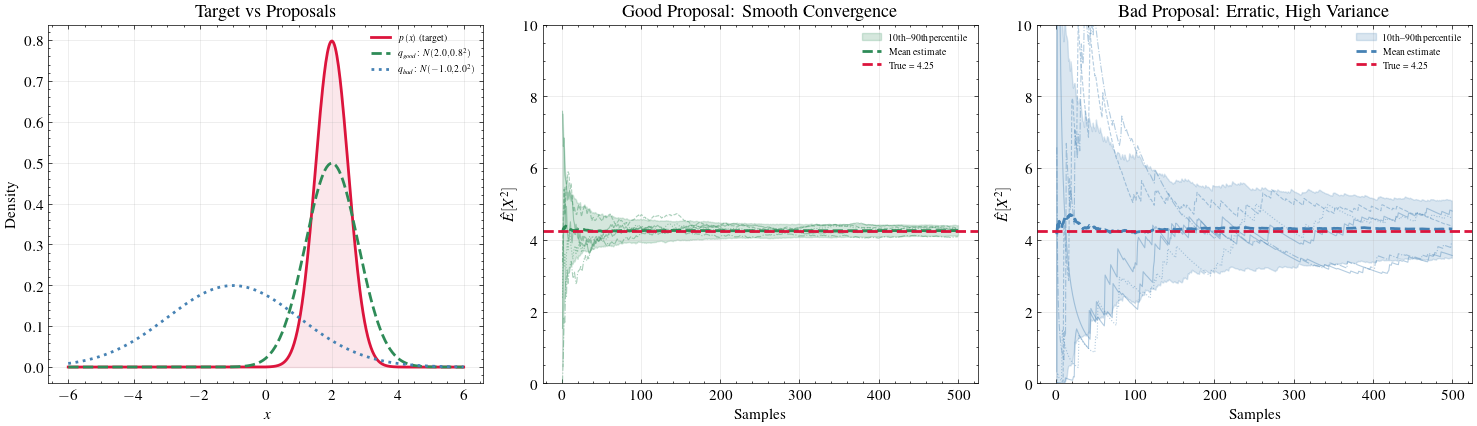

Good proposal — final estimates: mean=4.259, std=0.121
Bad proposal  — final estimates: mean=4.303, std=0.603
True value: 4.250


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

samples_axis = np.arange(1, n_samples + 1)

# (a) Proposal distributions
ax = axes[0]
x_plot = np.linspace(-6, 6, 500)
ax.plot(x_plot, stats.norm.pdf(x_plot, p_mu, p_sigma), 'crimson', lw=2, label='$p(x)$ (target)')
ax.fill_between(x_plot, stats.norm.pdf(x_plot, p_mu, p_sigma), alpha=0.1, color='crimson')
ax.plot(x_plot, stats.norm.pdf(x_plot, q_good_mu, q_good_sigma), 'seagreen', lw=2, ls='--',
        label=f'$q_{{good}}$: $N({q_good_mu}, {q_good_sigma}^2)$')
ax.plot(x_plot, stats.norm.pdf(x_plot, q_bad_mu, q_bad_sigma), 'steelblue', lw=2, ls=':',
        label=f'$q_{{bad}}$: $N({q_bad_mu}, {q_bad_sigma}^2)$')
ax.set_xlabel('$x$')
ax.set_ylabel('Density')
ax.set_title('Target vs Proposals')
ax.legend(fontsize=7)

# (b) Good proposal convergence — confidence bands + sample paths
ax = axes[1]
good_mean = np.mean(estimates_good, axis=0)
good_p10 = np.percentile(estimates_good, 10, axis=0)
good_p90 = np.percentile(estimates_good, 90, axis=0)
ax.fill_between(samples_axis, good_p10, good_p90, color='seagreen', alpha=0.2, label='10th–90th percentile')
for i in range(5):
    ax.plot(samples_axis, estimates_good[i], color='seagreen', alpha=0.4, lw=0.8)
ax.plot(samples_axis, good_mean, 'seagreen', lw=2, label='Mean estimate')
ax.axhline(true_val, color='crimson', ls='--', lw=2, label=f'True = {true_val:.2f}')
ax.set_xlabel('Samples')
ax.set_ylabel('$\\hat{E}[X^2]$')
ax.set_title('Good Proposal: Smooth Convergence')
ax.set_ylim(0, 10)
ax.legend(fontsize=7)

# (c) Bad proposal convergence — confidence bands + sample paths
ax = axes[2]
bad_mean = np.mean(estimates_bad, axis=0)
bad_p10 = np.percentile(estimates_bad, 10, axis=0)
bad_p90 = np.percentile(estimates_bad, 90, axis=0)
ax.fill_between(samples_axis, bad_p10, bad_p90, color='steelblue', alpha=0.2, label='10th–90th percentile')
for i in range(5):
    ax.plot(samples_axis, estimates_bad[i], color='steelblue', alpha=0.4, lw=0.8)
ax.plot(samples_axis, bad_mean, 'steelblue', lw=2, label='Mean estimate')
ax.axhline(true_val, color='crimson', ls='--', lw=2, label=f'True = {true_val:.2f}')
ax.set_xlabel('Samples')
ax.set_ylabel('$\\hat{E}[X^2]$')
ax.set_title('Bad Proposal: Erratic, High Variance')
ax.set_ylim(0, 10)
ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

print(f"Good proposal — final estimates: mean={np.mean(estimates_good[:,-1]):.3f}, std={np.std(estimates_good[:,-1]):.3f}")
print(f"Bad proposal  — final estimates: mean={np.mean(estimates_bad[:,-1]):.3f}, std={np.std(estimates_bad[:,-1]):.3f}")
print(f"True value: {true_val:.3f}")

### Animation: Importance Sampling Convergence

Side-by-side comparison of a good vs bad proposal. Watch how the good proposal converges smoothly, while the bad one is dominated by occasional extreme weights.

In [ ]:
np.random.seed(42)

n_samples_anim = 300

x_good_anim = np.random.normal(q_good_mu, q_good_sigma, n_samples_anim)
w_good_anim = stats.norm.pdf(x_good_anim, p_mu, p_sigma) / stats.norm.pdf(x_good_anim, q_good_mu, q_good_sigma)
g_good_anim = x_good_anim**2

x_bad_anim = np.random.normal(q_bad_mu, q_bad_sigma, n_samples_anim)
w_bad_anim = stats.norm.pdf(x_bad_anim, p_mu, p_sigma) / stats.norm.pdf(x_bad_anim, q_bad_mu, q_bad_sigma)
g_bad_anim = x_bad_anim**2

fig, axes = plt.subplots(2, 2, figsize=(13, 8), dpi=100)
plt.close(fig)

n_anim_frames_is = 100
step_is = max(1, n_samples_anim // n_anim_frames_is)

def animate_is(frame):
    n = min((frame + 1) * step_is, n_samples_anim)

    for ax in axes.flat:
        ax.clear()

    # Top left: good proposal - weights over time
    ax = axes[0, 0]
    ax.bar(range(n), w_good_anim[:n], color='seagreen', alpha=0.6, width=1.0)
    ax.set_ylabel('Weight $p/q$')
    ax.set_title(f'Good Proposal — Weights ($n={n}$)')
    ax.set_xlim(0, n_samples_anim)
    ax.set_ylim(0, max(w_good_anim.max(), w_bad_anim.max()) * 1.1)

    # Top right: bad proposal - weights over time
    ax = axes[0, 1]
    ax.bar(range(n), w_bad_anim[:n], color='steelblue', alpha=0.6, width=1.0)
    ax.set_ylabel('Weight $p/q$')
    ax.set_title(f'Bad Proposal — Weights ($n={n}$)')
    ax.set_xlim(0, n_samples_anim)
    ax.set_ylim(0, max(w_good_anim.max(), w_bad_anim.max()) * 1.1)

    # Bottom left: good proposal - running estimate
    ax = axes[1, 0]
    est_good_run = np.cumsum(g_good_anim[:n] * w_good_anim[:n]) / np.arange(1, n + 1)
    ax.plot(est_good_run, 'seagreen', lw=2)
    ax.axhline(true_val, color='crimson', ls='--', lw=2)
    ax.set_xlabel('Samples')
    ax.set_ylabel('$\\hat{E}[X^2]$')
    ax.set_title(f'Good Proposal — Estimate = {est_good_run[-1]:.2f}')
    ax.set_xlim(0, n_samples_anim)
    ax.set_ylim(0, 10)

    # Bottom right: bad proposal - running estimate
    ax = axes[1, 1]
    est_bad_run = np.cumsum(g_bad_anim[:n] * w_bad_anim[:n]) / np.arange(1, n + 1)
    ax.plot(est_bad_run, 'steelblue', lw=2)
    ax.axhline(true_val, color='crimson', ls='--', lw=2)
    ax.set_xlabel('Samples')
    ax.set_ylabel('$\\hat{E}[X^2]$')
    ax.set_title(f'Bad Proposal — Estimate = {est_bad_run[-1]:.2f}')
    ax.set_xlim(0, n_samples_anim)
    ax.set_ylim(0, 10)

    fig.tight_layout()

anim_is = FuncAnimation(fig, animate_is, frames=n_anim_frames_is, interval=120, repeat=False)
HTML(anim_is.to_jshtml())

> **The good proposal** has balanced weights — all samples contribute roughly equally, and the estimate converges smoothly. **The bad proposal** has a few samples with enormous weights that dominate the sum, making the estimate erratic.

---
## 5. Summary

| Method | What it needs | Strength | Mode of failure |
|---|---|---|---|
| **Inverse Transform Sampling** | Closed-form $F_X^{-1}$ | Exact samples, no waste | Most distributions don't have an invertible CDF |
| **Rejection Sampling** | A proposal $cg(x) \geq p(x)$ | Works for any evaluable target | Poor proposal leads to massive rejection rates |
| **Importance Sampling** | A proposal $q(x)$ with overlapping support | Doesn't discard samples; reweights instead | Bad $q$ causes extreme weights, unreliable estimates |

A pattern emerges: **the quality of your results depends on how well you understand the shape of the target distribution.** All three methods struggle in high dimensions — which is where **Markov Chain Monte Carlo (MCMC)** enters the picture.